<a href="https://colab.research.google.com/github/Samarthgarg27/Handwritten_Digit_Recognizer/blob/main/Hand_Written_Recognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets, layers, models

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


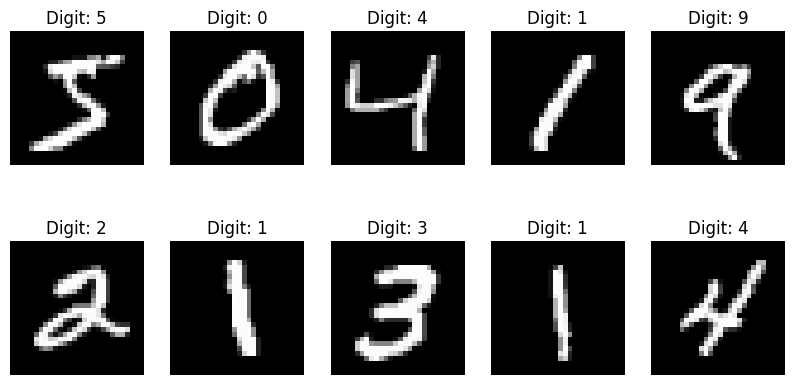

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Digit: {y_train[i]}")
    plt.axis('off')

plt.show()

In [ ]:
# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [ ]:
model = models.Sequential([

    # First convolution layer
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),

    # Reduce image size
    layers.MaxPooling2D((2, 2)),

    # Second convolution layer
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Reduce image size again
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Prevent overfitting
    layers.Dropout(0.5),

    # Output layer: digits 0-9
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.9207 - loss: 0.2621 - val_accuracy: 0.9835 - val_loss: 0.0549
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9735 - loss: 0.0889 - val_accuracy: 0.9887 - val_loss: 0.0391
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9798 - loss: 0.0664 - val_accuracy: 0.9907 - val_loss: 0.0374
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.9844 - loss: 0.0524 - val_accuracy: 0.9910 - val_loss: 0.0314
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9857 - loss: 0.0468 - val_accuracy: 0.9913 - val_loss: 0.0312
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.9878 - loss: 0.0401 - val_accuracy: 0.9917 - val_loss: 0.0332
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.9891 - loss: 0.0341 - val_accuracy: 0.9918 - val_loss: 0.0332
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.9904 - loss: 0.0288 - 

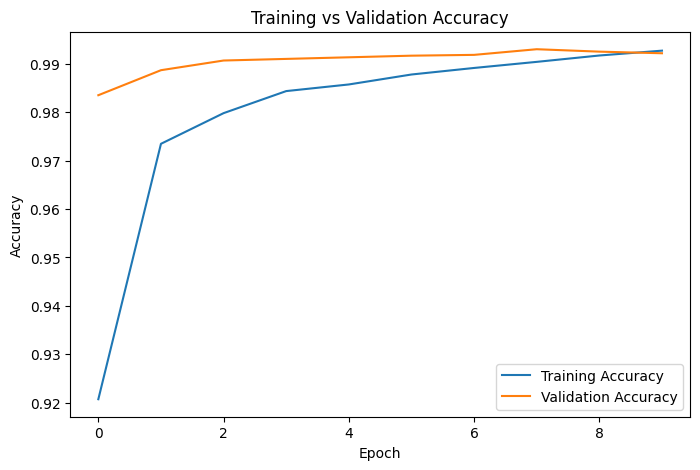

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

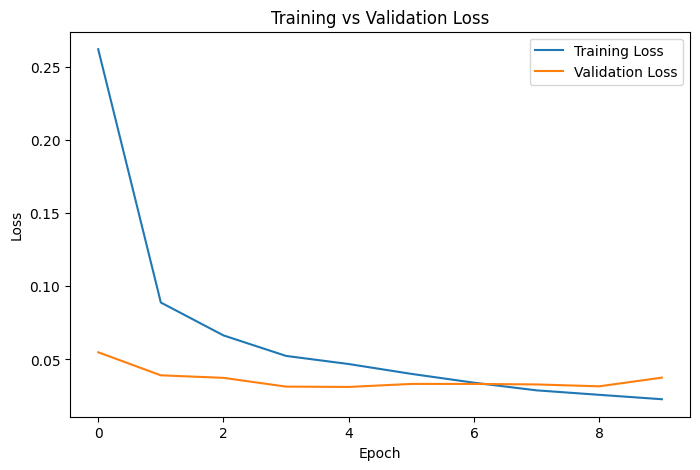

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9925 - loss: 0.0255
Test Loss: 0.025472193956375122
Test Accuracy: 0.9925000071525574


In [ ]:
predictions = model.predict(X_test)

# Convert probabilities into predicted classes
y_pred = np.argmax(predictions, axis=1)

print("Predicted:", y_pred[:20])
print("Actual:   ", y_test[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Predicted: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 5 4]
Actual:    [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


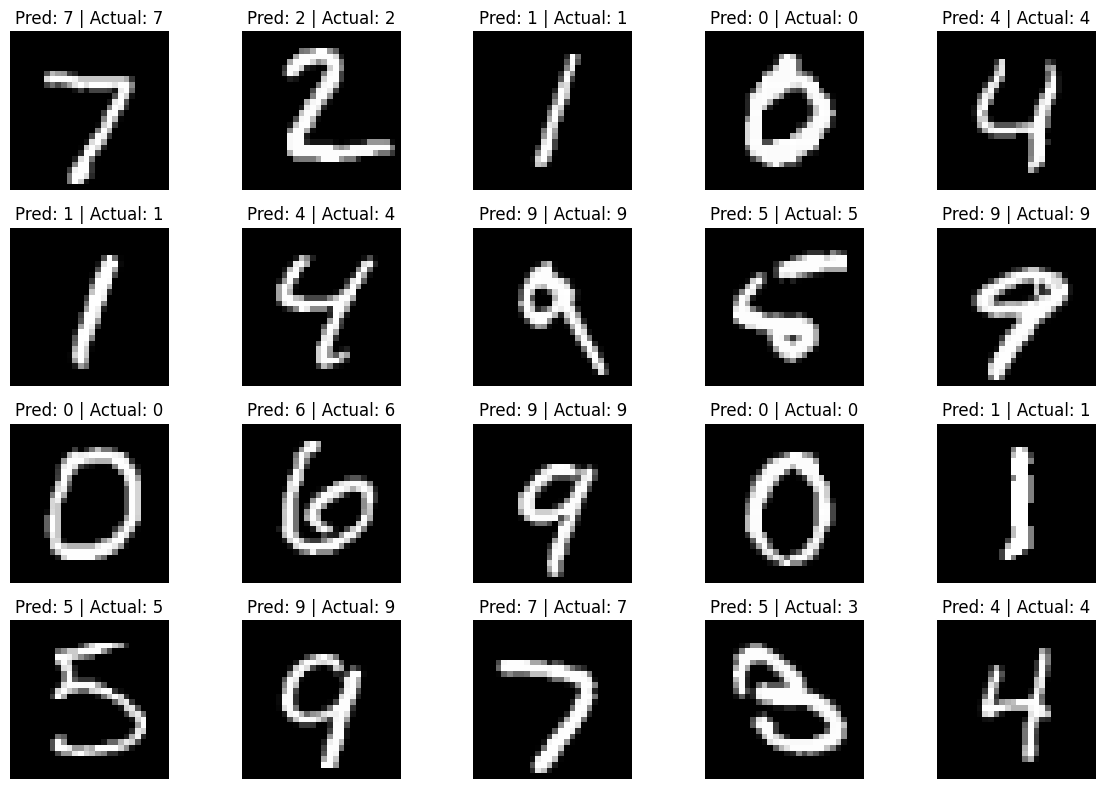

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    predicted = y_pred[i]
    actual = y_test[i]

    plt.title(f"Pred: {predicted} | Actual: {actual}")
    plt.axis('off')

plt.tight_layout()
plt.show()

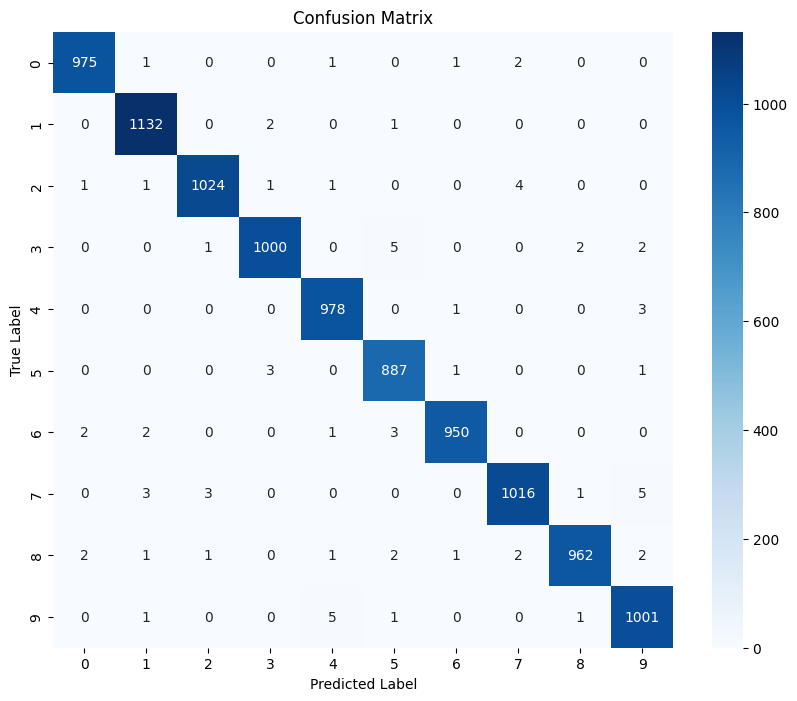

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


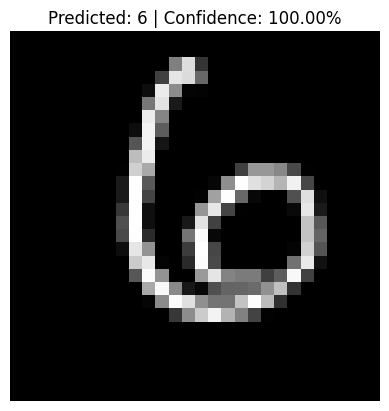

Predicted Digit: 6
Actual Digit: 6
Confidence: 100.00%


In [ ]:
index = 100

image = X_test[index]

prediction = model.predict(image.reshape(1, 28, 28, 1))

predicted_digit = np.argmax(prediction)

confidence = np.max(prediction) * 100

plt.imshow(image.reshape(28, 28), cmap='gray')
plt.axis('off')
plt.title(
    f"Predicted: {predicted_digit} | "
    f"Confidence: {confidence:.2f}%"
)

plt.show()

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[index])
print(f"Confidence: {confidence:.2f}%")

In [ ]:
incorrect = np.where(y_pred != y_test)[0]

print("Total incorrect predictions:", len(incorrect))

Total incorrect predictions: 75


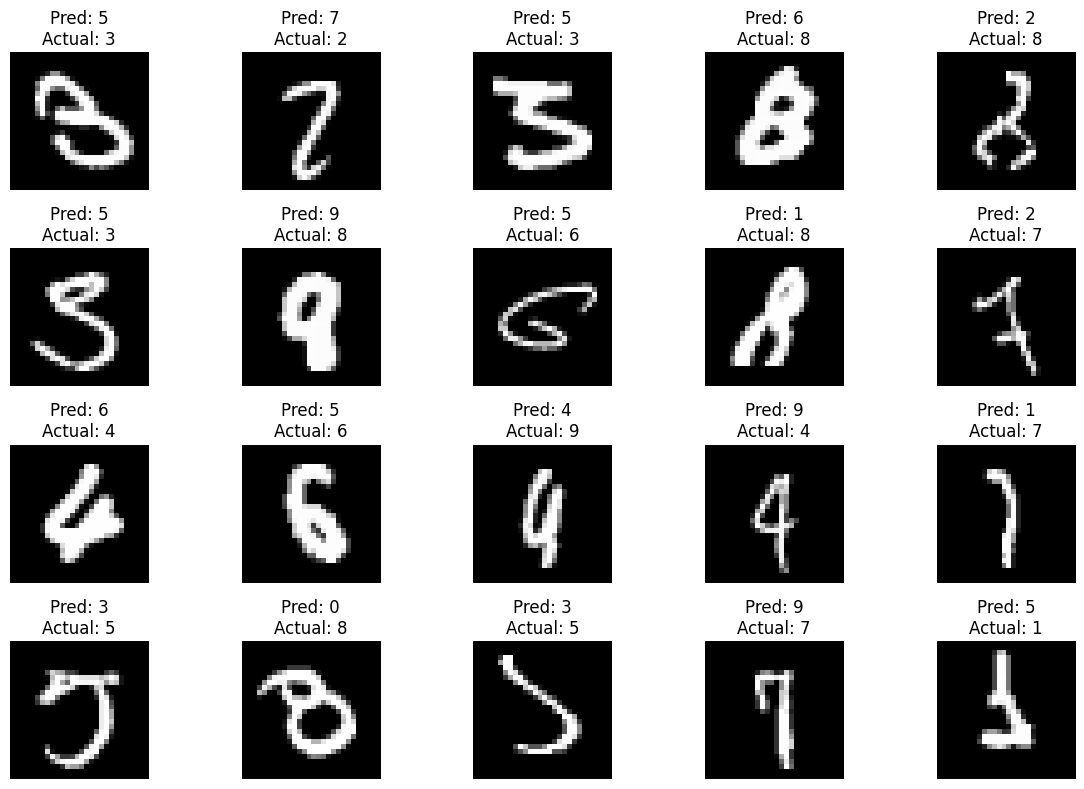

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(min(20, len(incorrect))):

    index = incorrect[i]

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X_test[index].reshape(28, 28),
        cmap='gray'
    )

    plt.title(
        f"Pred: {y_pred[index]}\n"
        f"Actual: {y_test[index]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()